In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [2]:
from sklearn.datasets import make_classification
x,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=1,n_redundant=0)
# \n_clusters_per_class=1 help to prevent overlapping in datapounts


In [3]:
df=pd.DataFrame(x)[0]
df



0     -1.056885
1     -1.354549
2     -1.356023
3     -1.144381
4     -1.461318
         ...   
995   -2.407604
996   -0.037974
997    0.544605
998   -1.336653
999   -0.299488
Name: 0, Length: 1000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

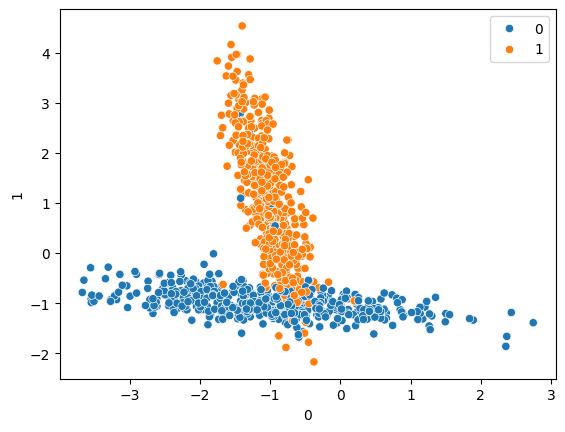

In [4]:
sns.scatterplot(x=pd.DataFrame(x)[0],y=pd.DataFrame(x)[1],hue=y)


In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


# IMPLEMEMNTING USING LINEAR SVC

In [6]:
## for this we will use linear SVC as points as linearly seperable
from sklearn.svm import SVC
svc=SVC(kernel='linear')
svc.fit(x_train,y_train)


SVC(kernel='linear')

In [7]:
svc_pred=svc.predict(x_test)

In [8]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(accuracy_score(y_test,svc_pred))
print(classification_report(y_test,svc_pred))
print(confusion_matrix(y_test,svc_pred))

0.95
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       100
           1       0.99      0.91      0.95       100

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200

[[99  1]
 [ 9 91]]


# IMPLEMENTING USING RBF SVC

In [9]:
rbf=SVC(kernel='rbf')
rbf.fit(x_train,y_train)
rbf_pred=rbf.predict(x_test)
print(accuracy_score(y_test,rbf_pred))  
print(classification_report(y_test,rbf_pred))
print(confusion_matrix(y_test,rbf_pred))

0.955
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       100
           1       0.98      0.93      0.95       100

    accuracy                           0.95       200
   macro avg       0.96      0.96      0.95       200
weighted avg       0.96      0.95      0.95       200

[[98  2]
 [ 7 93]]


# IMPLEMENTING POLYNOMIAL SVC

In [10]:
poly=SVC(kernel='poly')
poly.fit(x_train,y_train)
poly_pred=poly.predict(x_test)
print(accuracy_score(y_test,poly_pred))
print(classification_report(y_test,poly_pred))
print(confusion_matrix(y_test,poly_pred))


0.935
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       100
           1       0.94      0.93      0.93       100

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.93       200
weighted avg       0.94      0.94      0.93       200

[[94  6]
 [ 7 93]]


# SIGMOID SVC

In [11]:
sigma=SVC(kernel='sigmoid')
sigma.fit(x_train,y_train)
sigma_pred=poly.predict(x_test)
print(accuracy_score(y_test,sigma_pred))
print(classification_report(y_test,sigma_pred))
print(confusion_matrix(y_test,sigma_pred))

0.935
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       100
           1       0.94      0.93      0.93       100

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.93       200
weighted avg       0.94      0.94      0.93       200

[[94  6]
 [ 7 93]]


# HYPERPARAMETER TUNING USING GRID SEARCH CV


In [13]:
from sklearn.model_selection import GridSearchCV
param_grid={'C':[0.1,1,10,100],'gamma':[1, 0.1,0.01,0.001],'kernel':['rbf']}
grid=GridSearchCV(SVC(),param_grid,verbose=3,refit=True,cv=4,)

#verbose=0: (Default) No output messages are printed to the console. This is useful for silent operations or production runs.
#verbose=1: A single line is displayed, describing the total number of folds, candidates, and fits that will be executed.
#verbose=2: The output from level 1 is included, plus the computation time for each fold and parameter candidate is displayed.
#verbose=3 or higher: The output from level 2 is included, plus the fold and candidate parameter indexes, along with the starting time of the computation, are also displayed. Values above 10 may report all iterations. 

In [14]:
grid.fit(x_train,y_train)

Fitting 4 folds for each of 16 candidates, totalling 64 fits
[CV 1/4] END ........C=0.1, gamma=1, kernel=rbf;, score=0.965 total time=   0.0s
[CV 2/4] END ........C=0.1, gamma=1, kernel=rbf;, score=0.915 total time=   0.0s
[CV 3/4] END ........C=0.1, gamma=1, kernel=rbf;, score=0.960 total time=   0.0s
[CV 4/4] END ........C=0.1, gamma=1, kernel=rbf;, score=0.945 total time=   0.0s
[CV 1/4] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.935 total time=   0.0s
[CV 2/4] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.885 total time=   0.0s
[CV 3/4] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.935 total time=   0.0s
[CV 4/4] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.915 total time=   0.0s
[CV 1/4] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.860 total time=   0.0s
[CV 2/4] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.810 total time=   0.0s
[CV 3/4] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.870 total time=   0.0s
[CV 4/4] END .....C=0.1, gamma=0.01, kernel=rbf;

GridSearchCV(cv=4, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf']},
             verbose=3)

In [15]:
grid.best_params_

{'C': 10, 'gamma': 1, 'kernel': 'rbf'}

In [ ]:
y_pred=grid.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))


0.955
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       100
           1       0.96      0.95      0.95       100

    accuracy                           0.95       200
   macro avg       0.96      0.95      0.95       200
weighted avg       0.96      0.95      0.95       200

[[96  4]
 [ 5 95]]
